In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

plt.style.use('ggplot')

## Downloading real USDJPY data

In [13]:
df = yf.download('USDJPY=X',start='2020-01-01',end='2026-05-12')

df.shape

[*********************100%***********************]  1 of 1 completed


(1654, 5)

In [14]:
df = df['Close']
df.columns = ['Close']
df.head()

,Close
Date,
2020-01-01,108.681000
2020-01-02,108.712997
2020-01-03,108.542999
2020-01-06,107.963997
2020-01-07,108.405998


## Calculate EMA 20 and 50

In [15]:
df['ema_20'] = df['Close'].ewm(span=20,adjust=False).mean()
df['ema_50'] = df['Close'].ewm(span=50,adjust=False).mean()

df.head()

,Close,ema_20,ema_50
Date,,,
2020-01-01,108.681000,108.681000,108.681000
2020-01-02,108.712997,108.684047,108.682255
2020-01-03,108.542999,108.670614,108.676794
2020-01-06,107.963997,108.603317,108.648841
2020-01-07,108.405998,108.584525,108.639318


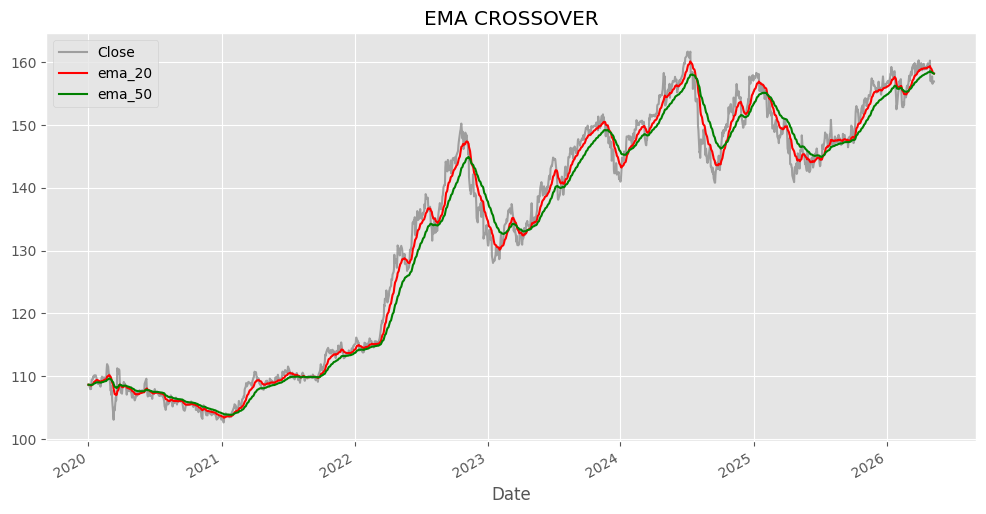

In [16]:
plt.figure(figsize=(12,6))

df['Close'].plot(color='grey',alpha=0.7)
df['ema_20'].plot(color='red')
df['ema_50'].plot(color='green')

# plt.xlim(df.index[-100], df.index[-1])   Zoom into last 100 days 

plt.title('EMA CROSSOVER')
plt.legend()
plt.show()

In [18]:
df['Signal'] = np.where(df['ema_20']>df['ema_50'],1,-1)
df.head()

,Close,ema_20,ema_50,Signal
Date,,,,
2020-01-01,108.681000,108.681000,108.681000,-1
2020-01-02,108.712997,108.684047,108.682255,1
2020-01-03,108.542999,108.670614,108.676794,-1
2020-01-06,107.963997,108.603317,108.648841,-1
2020-01-07,108.405998,108.584525,108.639318,-1


### Just with EMA Crossover

In [43]:
Log_Return = np.log(df['Close'] / df['Close'].shift(1))
df['Sys_Log_Return'] = Log_Return * df['Signal'].shift(1) # **
Annual_Volatility = (df["Sys_Log_Return"].std())*np.sqrt(252) 

df['Cum_Return'] = np.exp(df['Sys_Log_Return'].cumsum()) 
Rolling_max = df['Cum_Return'].cummax()  # **
df['Drawdown'] = (df['Cum_Return'] - Rolling_max) / Rolling_max
max_dd = df['Drawdown'].min()

Total_Return = df['Cum_Return'].iloc[-1] - 1
Annual_Return = np.exp(df['Sys_Log_Return'].mean() * 252) - 1

Daily_Sharpe = df['Sys_Log_Return'].mean() / df['Sys_Log_Return'].std()
Annual_Sharpe = Daily_Sharpe * np.sqrt(252)

### Volatility filter

In [44]:
# Calculate rolling volatility
df['Volatility'] = df['Sys_Log_Return'].rolling(20).std()

# Only take signals when volatility is above its median
vol_median = df['Volatility'].median()

# Filter signal — if volatility too low, go flat (0)
df['Filtered_Signal'] = np.where(df['Volatility'] > vol_median, df['Signal'],0)

# Recalculate with filtered signal
df['Sys_Log_Return_F'] = Log_Return * df['Filtered_Signal'].shift(1)

In [45]:
Annual_Volatility_F = (df["Sys_Log_Return_F"].std())*np.sqrt(252)

df['Cum_Return_F'] = np.exp(df['Sys_Log_Return_F'].cumsum())  
Rolling_max_F = df['Cum_Return_F'].cummax()  # **
df['Drawdown_F'] = (df['Cum_Return_F'] - Rolling_max_F) / Rolling_max_F
max_dd_F = df['Drawdown_F'].min()

Total_Return_F = df['Cum_Return_F'].iloc[-1] - 1
Annual_Return_F = np.exp(df['Sys_Log_Return_F'].mean() * 252) - 1

Daily_Sharpe_F = df['Sys_Log_Return_F'].mean() / df['Sys_Log_Return_F'].std()
Annual_Sharpe_F = Daily_Sharpe_F * np.sqrt(252)

## Report Card for both Volatility filter n just EMA Crossover

In [46]:
print('='*45)
print('USDJPY EMA CROSSOVER WITH AND WITHOUT FILTER — REPORT CARD')
print('='*45)
print(f'Annual Volatility - Filtered: {Annual_Volatility_F:.4f} vs Not Filtered: {Annual_Volatility:.4f}')
print(f'Total Return - Filtered: {Total_Return_F:.2%} vs  Not Filtered: {Total_Return:.2%}')
print(f'Annual Return - Filtered: {Annual_Return_F:.2%} vs Not Filtered: {Annual_Return:.2%}')
print(f'Annual Sharpe Ratio - Filtered: {Annual_Sharpe_F:.4f} vs Not Filtered: {Annual_Sharpe:.4f}')
print(f'Maximum Drawdown - Filtered: {max_dd_F:.2%} vs  Not Filtered: {max_dd:.2%}')

USDJPY EMA CROSSOVER WITH AND WITHOUT FILTER — REPORT CARD
Annual Volatility - Filtered: 0.0797 vs Not Filtered: 0.0932
Total Return - Filtered: 31.95% vs  Not Filtered: 43.85%
Annual Return - Filtered: 4.32% vs Not Filtered: 5.70%
Annual Sharpe Ratio - Filtered: 0.5305 vs Not Filtered: 0.5945
Maximum Drawdown - Filtered: -11.41% vs  Not Filtered: -11.99%
